 KNN CLASSFIFICATION (Supervised learning)
 This is used to classify a point that has been presented to us based on the K points nearest to it
 The nearest neighbours are decided based on the eucledian distance from the required point
 It's possible to over shott or undershoot the value of K thus trials are needed
 

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Load the dataset
df = pd.read_csv('star_classification.csv')
# Preprocess the data
print(df.isnull().sum())  # Check for missing values

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64


In [37]:
features = df[['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']]
# We don't use all the available features for this task as not all of them are directly 
# relevant to the Target variable that is class. This will be relevant in decision trees as well
X= features
Y = df['class']


We try to always use test train split on our data to make sure that our model isn't straight up fed the answers but instead uses a portion of the data to learn and the other bit to checkhow accurate our model actually is

In [38]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(80000, 8) (20000, 8) (80000,) (20000,)


Rescaling our values is needed as it helps our model understand the data on similar scales and making the process faster and more accurate there's pretty much no downside to it so it's better to be doing so

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled[:5])  # Print the first 5 rows of the scaled training data To check the scaling

[[-0.23360626  0.78062858  0.01023503  0.0251797   0.46647032  0.30829143
   0.01983167  0.11297309]
 [-1.53919578  0.45648711  0.10973563  0.10478384  0.99034775  0.73918686
   0.02096951  0.32340432]
 [-0.35057849 -0.37024055  0.01882714  0.02564556 -0.05406592 -0.11797274
  -0.00693785 -0.2363912 ]
 [-0.23675609  0.53674466 -0.0478785  -0.0556267  -1.11338023 -1.08979883
  -0.05048112 -0.64021836]
 [ 0.36242184  0.62581114  0.00224798  0.02698     0.90633832  1.23812321
   0.07124816 -0.79041016]]


In [40]:
#Actually appyling the KNN algorithm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
for k in [1,3,5,7,9,11]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    print(f"K={k}: {accuracy_score(y_test, y_pred)*100:.2f}%")

#We tested our model with different values of K and can see the K=3 or 5 Gives the best accuracy
#W check the clasification report for k=5
print("Classification report for K=5:")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
# We can also print the classification report for K=3
print("Classification report for K=3:")
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

K=1: 93.56%
K=3: 94.39%
K=5: 94.38%
K=7: 94.30%
K=9: 94.08%
K=11: 93.84%
Classification report for K=5:
              precision    recall  f1-score   support

      GALAXY       0.95      0.96      0.95     11860
         QSO       0.96      0.89      0.93      3797
        STAR       0.92      0.94      0.93      4343

    accuracy                           0.94     20000
   macro avg       0.94      0.93      0.94     20000
weighted avg       0.94      0.94      0.94     20000

Classification report for K=3:
              precision    recall  f1-score   support

      GALAXY       0.95      0.96      0.95     11860
         QSO       0.96      0.89      0.93      3797
        STAR       0.92      0.94      0.93      4343

    accuracy                           0.94     20000
   macro avg       0.94      0.93      0.94     20000
weighted avg       0.94      0.94      0.94     20000



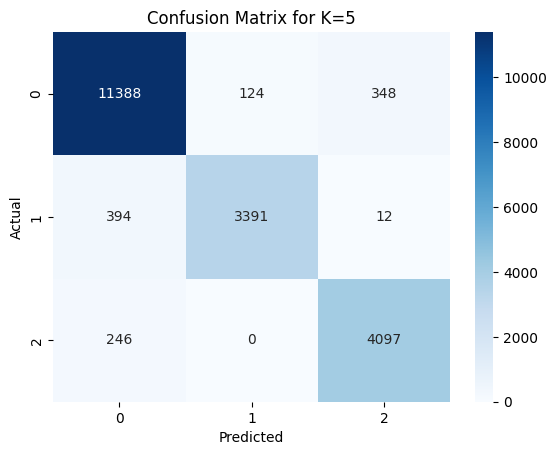

In [41]:

# Confusion matrix for K=5  
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for K=5')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

DECISION TREES (Supervised learning)
Not accurate but in simple to understand terms they just split your data into a bunch of nested if and else statements and classify them under a category eventually

Classification report for Decision Tree:
              precision    recall  f1-score   support

      GALAXY       0.97      0.97      0.97     11860
         QSO       0.91      0.91      0.91      3797
        STAR       1.00      0.99      0.99      4343

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000

Accuracy for Decision Tree: 96.39%


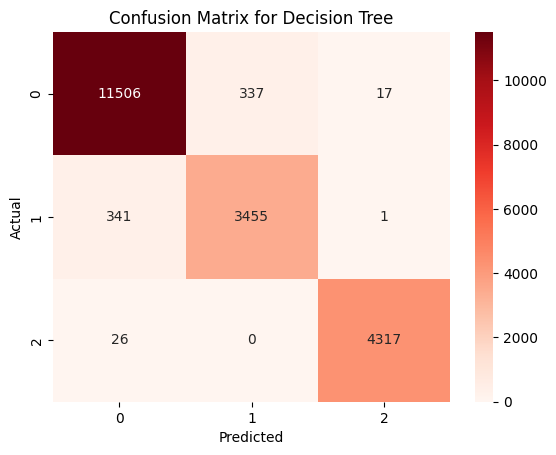

In [42]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
print("Classification report for Decision Tree:")
print(classification_report(y_test, y_pred_dt))
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy for Decision Tree: {accuracy_dt*100:.2f}%")

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix for Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

K MEANS ALGORITHM (Unsupervised Learning)
Unlike the other 2 this algorithm doesn't have a whole explicit target variable and we need to define it in clusters

In [43]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)
cluster_labels = kmeans.labels_ # Assigning the lables to the classes in the dataset as 0,1,2
print("Cluster labels for the training data:")
print(cluster_labels[:10])  # Print the first 10 cluster labels for the training data
print(f"Sum of squared distances to cluster centers: {kmeans.inertia_}") #checl how compact the cluster are
silhouette_avg = silhouette_score(X_train_scaled, cluster_labels)
print(f"Silhouette Score for KMeans clustering: {silhouette_avg:.4f}")

#The score from -1 to 1 is 0.30 which is basically moderately decent clustering

Cluster labels for the training data:
[2 2 2 0 2 2 0 2 2 0]
Sum of squared distances to cluster centers: 269712.8847581877
Silhouette Score for KMeans clustering: 0.3019


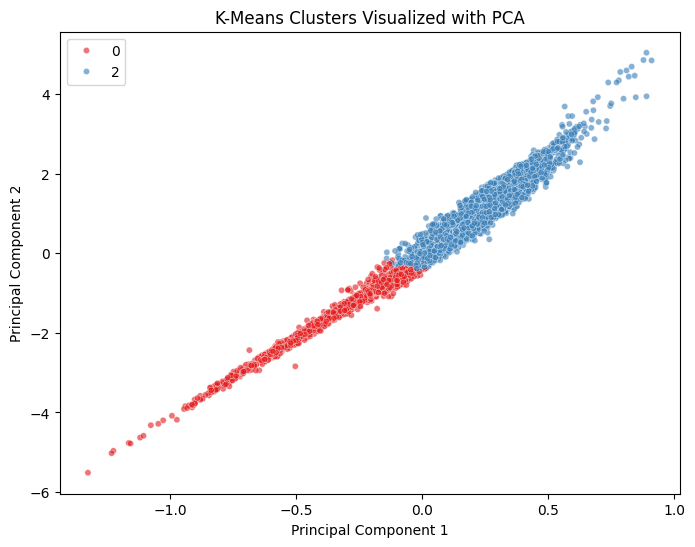

In [44]:
#Using principal component analysis to visualize the clusters
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
import numpy as np

idx = np.random.choice(len(X_train_pca), 5000, replace=False)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_train_pca[idx,0],
    y=X_train_pca[idx,1],
    hue=cluster_labels[idx],
    palette='Set1',
    alpha=0.6,
    s=20
)

plt.title("K-Means Clusters Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [45]:
import pandas as pd
import numpy as np

print("Unique clusters:", np.unique(cluster_labels))

print("\nCluster counts:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Unique clusters: [0 1 2]

Cluster counts:
0    30108
1        1
2    49891
Name: count, dtype: int64
